## 메인퀘스트 평가 기준
1. 모평균과 표본평균에 대한 차이를 설명하고, 독립표본 t 검정을 시행함
2. 적절한 시각화를 통해 데이터의 분포를 설명함
3. 다중 선형 회귀 분석을 시행하고 결과를 해석함
4. 적절한 특성들을 기반으로 로지스틱 회귀 모델을 학습시키고 모델을 평가함
5. 로지스틱 회귀 모델의 성능을 높이기 위한 시도를 진행함

## 데이터 제공

In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [87]:
!pip install kagglehub

In [88]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("tunguz/online-retail")

print("Path to dataset files:", path)
df = pd.read_csv(path + '/' + os.listdir(path)[0], encoding='latin1')
df.shape

Using Colab cache for faster access to the 'online-retail' dataset.
Path to dataset files: /kaggle/input/online-retail


(541909, 8)

In [89]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom


In [90]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [91]:
# 주문 가격 피쳐 생성
df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom,20.34


In [92]:
# 'InvoiceDate' 컬럼을 이용하여 주중과 주말을 구분
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['DayOfWeek'] = df['InvoiceDate'].dt.dayofweek

# 'InvoiceDate' 컬럼 이용하여 판매 월 추출
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"].astype(str))
df["InvoiceMonth"] = df["InvoiceDate"].dt.month
df.head()

/tmp/ipython-input-3046226245.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,DayOfWeek,InvoiceMonth
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2,12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2,12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2,12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2,12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2,12


## 결측치 확인/처리

In [93]:
# 결측치 확인
df.isna().mean()
# CustomerID	0.249267 결측치가 가장 많으나 데이터 분석에는 이상 없을 것으로 판단

,0
InvoiceNo,0.000000
StockCode,0.000000
Description,0.002683
Quantity,0.000000
InvoiceDate,0.000000
UnitPrice,0.000000
CustomerID,0.249267
Country,0.000000
TotalPrice,0.000000
DayOfWeek,0.000000


## 이상치 확인/처리

In [94]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 11 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   InvoiceNo     541909 non-null  object        
 1   StockCode     541909 non-null  object        
 2   Description   540455 non-null  object        
 3   Quantity      541909 non-null  int64         
 4   InvoiceDate   541909 non-null  datetime64[ns]
 5   UnitPrice     541909 non-null  float64       
 6   CustomerID    406829 non-null  float64       
 7   Country       541909 non-null  object        
 8   TotalPrice    541909 non-null  float64       
 9   DayOfWeek     541909 non-null  int32         
 10  InvoiceMonth  541909 non-null  int32         
dtypes: datetime64[ns](1), float64(3), int32(2), int64(1), object(4)
memory usage: 41.3+ MB


In [95]:
df.describe()
# Quantity 컬럼기준 최소, 최대 극단값 보임, 확인 필요

,Quantity,InvoiceDate,UnitPrice,CustomerID,TotalPrice,DayOfWeek,InvoiceMonth
count,541909.000000,541909,541909.000000,406829.000000,541909.000000,541909.000000,541909.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570,17.987795,2.431277,7.553128
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000,-168469.600000,0.000000,1.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000,3.400000,1.000000,5.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000,9.750000,2.000000,8.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000,17.400000,4.000000,11.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000,168469.600000,6.000000,12.000000
std,218.081158,NaN,96.759853,1713.600303,378.810824,1.844709,3.509055


In [96]:
# 데이터 확인 (시각화)
df.sort_values("Quantity")

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,DayOfWeek,InvoiceMonth
540422,C581484,23843,"PAPER CRAFT , LITTLE BIRDIE",-80995,2011-12-09 09:27:00,2.08,16446.0,United Kingdom,-168469.6,4,12
61624,C541433,23166,MEDIUM CERAMIC TOP STORAGE JAR,-74215,2011-01-18 10:17:00,1.04,12346.0,United Kingdom,-77183.6,1,1
225529,556690,23005,printing smudges/thrown away,-9600,2011-06-14 10:37:00,0.00,NaN,United Kingdom,-0.0,1,6
225530,556691,23005,printing smudges/thrown away,-9600,2011-06-14 10:37:00,0.00,NaN,United Kingdom,-0.0,1,6
4287,C536757,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,-9360,2010-12-02 14:23:00,0.03,15838.0,United Kingdom,-280.8,3,12
...,...,...,...,...,...,...,...,...,...,...,...
421632,573008,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,4800,2011-10-27 12:26:00,0.21,12901.0,United Kingdom,1008.0,3,10
74614,542504,37413,NaN,5568,2011-01-28 12:03:00,0.00,NaN,United Kingdom,0.0,4,1
502122,578841,84826,ASSTD DESIGN 3D PAPER STICKERS,12540,2011-11-25 15:57:00,0.00,13256.0,United Kingdom,0.0,4,11
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346.0,United Kingdom,77183.6,1,1


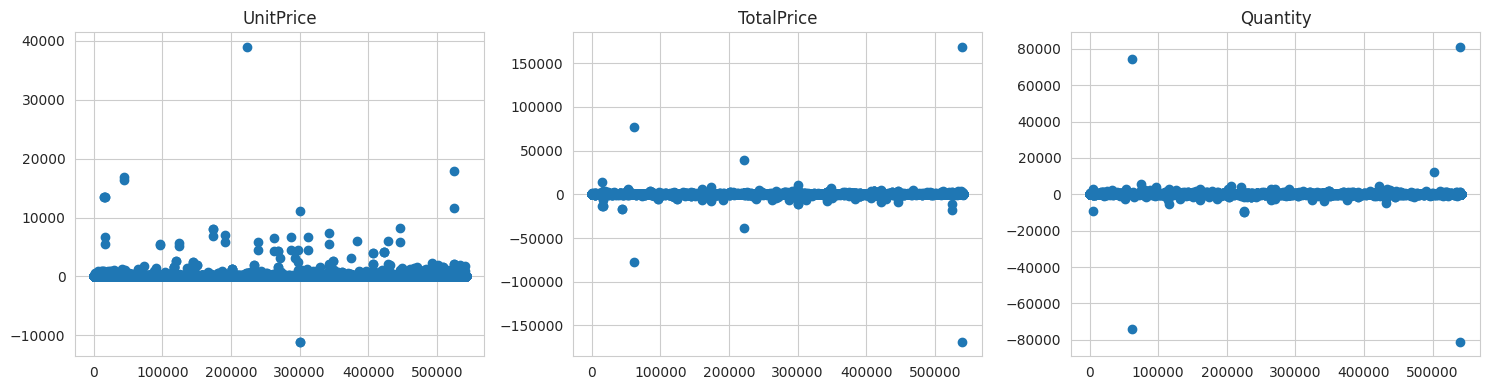

In [97]:
# 데이터 확인 (시각화)
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)

axes[0].scatter(df.index, df["UnitPrice"])
axes[0].set_title("UnitPrice")

axes[1].scatter(df.index, df["TotalPrice"])
axes[1].set_title("TotalPrice")

axes[2].scatter(df.index, df["Quantity"])
axes[2].set_title("Quantity")

plt.tight_layout()
plt.show()

In [98]:
# 극단값으로 인해 데이터 분석, 시각화 어려움이 있을 것으로 예상되므로
# Quantity, UnitPrice 컬럼 기준 중앙에서 90% 이내의 값만 사용 (10 ~ 90% 범위 제거)
cols = ["Quantity", "UnitPrice"]
q_low, q_high = 0.1, 0.90  #  하위 10% 제거 + 상위 10% 제거
lo = df[cols].quantile(q_low)
hi = df[cols].quantile(q_high)

mask = df[cols].ge(lo).all(axis=1) & df[cols].le(hi).all(axis=1)
df_trim = df.loc[mask].copy()
df_trim.head

<bound method NDFrame.head of        InvoiceNo StockCode                          Description  Quantity  \
0         536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1         536365     71053                  WHITE METAL LANTERN         6   
2         536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3         536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4         536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
...          ...       ...                                  ...       ...   
541904    581587     22613          PACK OF 20 SPACEBOY NAPKINS        12   
541905    581587     22899         CHILDREN'S APRON DOLLY GIRL          6   
541906    581587     23254        CHILDRENS CUTLERY DOLLY GIRL          4   
541907    581587     23255      CHILDRENS CUTLERY CIRCUS PARADE         4   
541908    581587     22138        BAKING SET 9 PIECE RETROSPOT          3   

               InvoiceDate  UnitPrice  CustomerID         Country  TotalPrice  \
0      2010-12-01 08:26:00       2.55     17850.0  United Kingdom       15.30   
1      2010-12-01 08:26:00       3.39     17850.0  United Kingdom       20.34   
2      2010-12-01 08:26:00       2.75     17850.0  United Kingdom       22.00   
3      2010-12-01 08:26:00       3.39     17850.0  United Kingdom       20.34   
4      2010-12-01 08:26:00       3.39     17850.0  United Kingdom       20.34   
...                    ...        ...         ...             ...         ...   
541904 2011-12-09 12:50:00       0.85     12680.0          France       10.20   
541905 2011-12-09 12:50:00       2.10     12680.0          France       12.60   
541906 2011-12-09 12:50:00       4.15     12680.0          France       16.60   
541907 2011-12-09 12:50:00       4.15     12680.0          France       16.60   
541908 2011-12-09 12:50:00       4.95     12680.0          France       14.85   

        DayOfWeek  InvoiceMonth  
0               2            12  
1               2            12  
2               2            12  
3               2            12  
4               2            12  
...           ...           ...  
541904          4            12  
541905          4            12  
541906          4            12  
541907          4            12  
541908          4            12  

[413143 rows x 11 columns]>

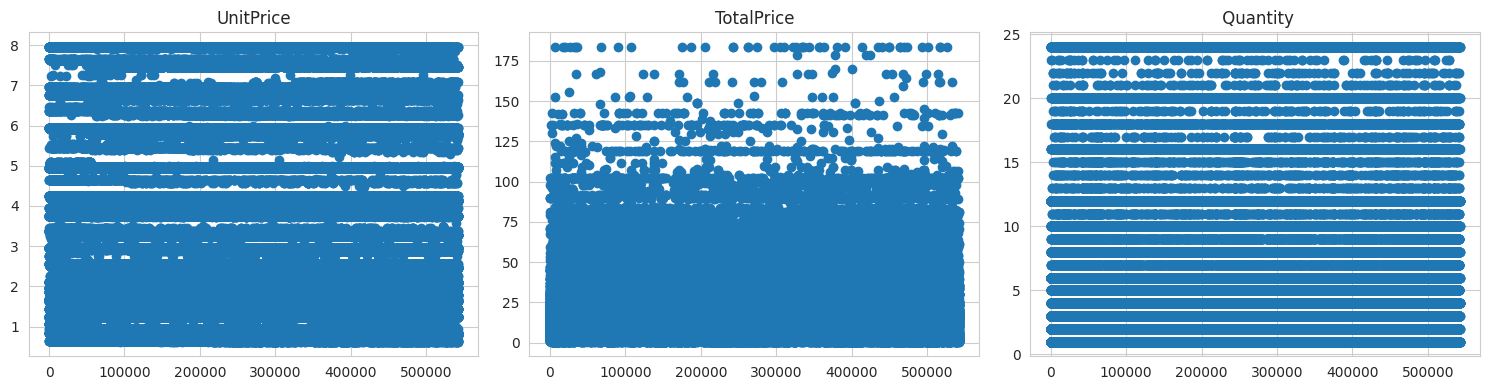

In [99]:
# 데이터 재확인 (시각화)
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)

axes[0].scatter(df_trim.index, df_trim["UnitPrice"])
axes[0].set_title("UnitPrice")

axes[1].scatter(df_trim.index, df_trim["TotalPrice"])
axes[1].set_title("TotalPrice")

axes[2].scatter(df_trim.index, df_trim["Quantity"])
axes[2].set_title(" Quantity")

plt.tight_layout()
plt.show()

In [100]:
# 극단값 제거 시 제거율 3.85%, 데이터 손실 과도하지 않은 것으로
removed = len(df) - len(df_trim)
print("행 제거율:", removed, " / ", len(df), " (", removed/len(df), ")")

행 제거율: 128766  /  541909  ( 0.23761554061659798 )


In [101]:
df_trim['TotalPrice'].value_counts()

,count
TotalPrice,
15.00,20123
1.25,9550
2.46,9275
17.70,9250
4.13,8810
...,...
11.84,1
82.50,1
7.52,1


## 1. 모집단과 표본 집단의 TotalPrice를 비교해 주세요.

* 데이터셋에서 무작위로 1000개의 표본을 추출하세요.
* 추출된 표본과 전체 데이터셋의 'TotalPrice'에 대해 평균과 표준편차를 비교해주세요.  
* 중심극한정리를 사용해 모집단과 표본의 차이를 설명해주세요.

In [102]:
# Q. 데이터셋에서 무작위로 1000개의 표본을 추출하세요.

# 이때 n은 뽑을 행 개수, random_state는 같은 표본을 다시 얻기 위한 시드값
sample = df.sample(n=1000, random_state=100)
sample.head()

# =========================[코드참고]=========================
# if 데이터가 1000행 미만일 때
# 가능한 만큼만 뽑기 (중복 없이)
# sample_df = df.sample(n=min(1000, len(df)), random_state=42)

# 1000개를 꼭 뽑아야 하면 (중복 허용: 복원추출)
# sample_df = df.sample(n=1000, replace=True, random_state=42)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,DayOfWeek,InvoiceMonth
411471,572219,22385,JUMBO BAG SPACEBOY DESIGN,2,2011-10-21 13:17:00,2.08,17463.0,United Kingdom,4.16,4,10
404371,571672,84029E,RED WOOLLY HOTTIE WHITE HEART.,12,2011-10-18 13:15:00,4.25,13880.0,United Kingdom,51.00,1,10
221035,556237,79000,MOROCCAN TEA GLASS,60,2011-06-09 15:34:00,1.65,NaN,United Kingdom,99.00,3,6
68908,541880,20719,WOODLAND CHARLOTTE BAG,20,2011-01-24 10:38:00,0.85,13819.0,United Kingdom,17.00,0,1
524089,580527,22475,SKULL DESIGN TV DINNER TRAY,2,2011-12-04 15:19:00,1.95,13736.0,United Kingdom,3.90,6,12


In [103]:
# Q. 추출된 표본과 전체 데이터셋의 'TotalPrice'에 대해 평균과 표준편차를 비교해주세요.
print('모집단 평균:', round(df["TotalPrice"].mean(),2))
print('샘플 평균:',round(sample["TotalPrice"].mean(),2))
print('모집단 표준편차:',round(df["TotalPrice"].std(),2))
print('샘플 표준편차:',round(sample["TotalPrice"].std(),2))

모집단 평균: 17.99
샘플 평균: 20.84
모집단 표준편차: 378.81
샘플 표준편차: 73.41


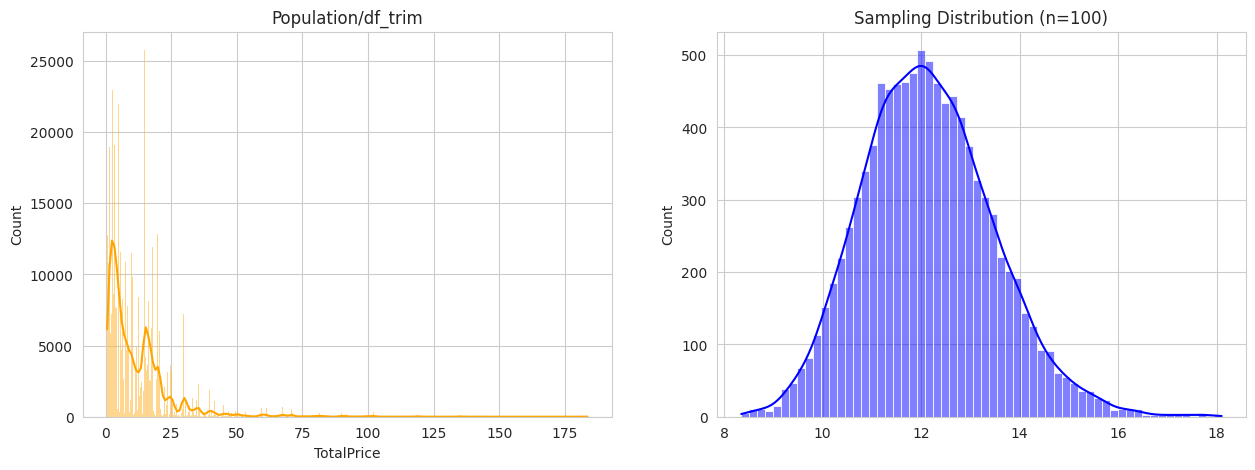

모집단 평균: 12.14
표본 평균들의 평균: 12.14


"\n=========================[중심극한 정리 관련]=========================\n1. 모집단\n  - 매우 강한 우측 왜도를 보이며 0 근처에 밀집\n  - 상위 1%의 극단적 이상치가 평균 추정을 방해함\n\n2. 표본 평균의 분포\n - 상위 1% 이상치 제거 후, 이론에 부합하는 완벽한 종 모양정규분포 형성\n\n3. 모집단 vs 표본의 주요 차이\n  - 모집단은 비정규 분포이나, 표본 평균의 분포는'정규 분포'에 수렴\n  - 현실 데이터에서 CLT를 증명하려면 극단적 이상치(Outliers) 제어 필수\n"

In [104]:
# Q. 중심극한정리를 사용해 모집단과 표본의 차이를 설명해주세요.

# df_trim에서 분석할 컬럼 선택 (TotalPrice)
population = df_trim["TotalPrice"]

# 중심극한정리 실행
sample_means = []
n = 100            # 표본의 크기
iterations = 10000 # 반복 횟수

for _ in range(iterations):   # 모집단에서 n개를 비복원 추출하여 평균 계산
    sample = population.sample(n=n, replace=False)
    sample_means.append(sample.mean())

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 모집단 분포
sns.histplot(population, kde=True, ax=axes[0], color='orange')
axes[0].set_title("Population/df_trim")

# 표본 평균의 분포
sns.histplot(sample_means, kde=True, ax=axes[1], color='blue')
axes[1].set_title(f"Sampling Distribution (n={n})")

plt.show()

# 4. 수치적 검증
print(f"모집단 평균: {population.mean():.2f}")
print(f"표본 평균들의 평균: {np.mean(sample_means):.2f}")

"""
=========================[중심극한 정리 관련]=========================
1. 모집단
  - 매우 강한 우측 왜도를 보이며 0 근처에 밀집
  - 상위 1%의 극단적 이상치가 평균 추정을 방해함

2. 표본 평균의 분포
 - 상위 1% 이상치 제거 후, 이론에 부합하는 완벽한 종 모양정규분포 형성

3. 모집단 vs 표본의 주요 차이
  - 모집단은 비정규 분포이나, 표본 평균의 분포는'정규 분포'에 수렴
  - 현실 데이터에서 CLT를 증명하려면 극단적 이상치(Outliers) 제어 필수
"""

## 2. 주문이 가장 많은 상위 두 국가의 'TotalPrice' 평균에 차이가 있는지 검증하세요.

* 'Country' 변수를 바탕으로 주문이 가장 많은 상위 두 국가를 찾으세요.
* 독립표본 t-검정을 사용하여 두 국가 간 'TotalPrice' 평균의 차이가 통계적으로 유의미한지 검증하세요.  
* t-통계량과 p-값을 해석하여 결과를 설명하고, 1종 오류와 2종 오류의 개념을 적용하여 설명해주세요.

In [105]:
# Q. 'Country' 변수를 바탕으로 주문이 가장 많은 상위 두 국가를 찾으세요.
top_countries = df.groupby('Country')['InvoiceNo'].nunique().sort_values(ascending=False).head()
top_countries
# 상위 두 국가 = United Kingdom	, Germany

,InvoiceNo
Country,
United Kingdom,23494
Germany,603
France,461
EIRE,360
Belgium,119


In [106]:
# Q. 독립표본 t-검정을 사용하여 두 국가 간 'TotalPrice' 평균의 차이가 통계적으로 유의미한지 검증하세요.

# 두 국가의 TotalPrice 컬럼 데이터 추출 (불리언 마스크 사용 )
uk = df_trim.loc[df_trim["Country"] == "United Kingdom", "TotalPrice"]
de = df_trim.loc[df_trim["Country"] == "Germany", "TotalPrice"]

# Welch t-test (분산 동일 가정 X)
result = stats.ttest_ind(uk, de, equal_var=False, alternative="two-sided")
print("t 값:", result.statistic)
print("p 값:", result.pvalue)


print("UK 평균:", uk.mean())
print("DE 평균:", de.mean())
print("평균차이 (UK-DE):", uk.mean() - de.mean())

# ====================================================================================================


# Q . t-통계량과 p-값을 해석하여 결과를 설명하고, 1종 오류와 2종 오류의 개념을 적용하여 설명해주세요.
"""
=========================[독립표본 t-검정 수행 결과]=========================
1. t 값: -50.72
  - UK 평균이 Germany 평균보다 작은 경향성 차이가 보임

2. p 값: 0.0
 - UK와 Germany의 TotalPrice 평균이 같다는 귀무가설 기각
 - scipy 에서 p=0.0은 보통 표현 가능한 범위보다 너무 작아 0.0으로 출력된 것이라서 p≤α 성립

3. 1종 오류/2종 오류
  - 1종 오류: 실제 UK와 DE의 평균이 같은데(귀무가설이 참인데) “다르다”고 결론,α로 통제
  - 2종 오류: 실제로는 모평균이 다른데(귀무가설이 거짓인데) “차이가 없다”고 결론

※ 주의 사항
  - 표본 수가 매우 크면, 평균 차이가 아주 작아도 p-value가 극단적으로 작아져 유의가 나올 수 있음
  - p 값 과 함께 평균 차이를 같이 확인할 필요 있음
  - 평균차이가 거의 40% 이므로 유의한 것으로 보임

"""


t 값: -50.729412785568215
p 값: 0.0
UK 평균: 11.479789035835616
DE 평균: 19.98819174041298
평균차이 (UK-DE): -8.508402704577364


'\n=========================[독립표본 t-검정 수행 결과]=========================\n1. t 값: -50.72\n  - UK 평균이 Germany 평균보다 작은 경향성 차이가 보임\n\n2. p 값: 0.0  \n - UK와 Germany의 TotalPrice 평균이 같다는 귀무가설 기각\n - scipy 에서 p=0.0은 보통 표현 가능한 범위보다 너무 작아 0.0으로 출력된 것이라서 p≤α 성립\n\n3. 1종 오류/2종 오류\n  - 1종 오류: 실제 UK와 DE의 평균이 같은데(귀무가설이 참인데) “다르다”고 결론,α로 통제\n  - 2종 오류: 실제로는 모평균이 다른데(귀무가설이 거짓인데) “차이가 없다”고 결론\n\n※ 주의 사항 \n  - 표본 수가 매우 크면, 평균 차이가 아주 작아도 p-value가 극단적으로 작아져 유의가 나올 수 있음\n  - p 값 과 함께 평균 차이를 같이 확인할 필요 있음\n  - 평균차이가 거의 40% 이므로 유의한 것으로 보임 \n\n'

## 3. 주중, 주말에 따라서 발생하는 UnitPrice의 분포가 달라지는지 확인하세요.

* 주중의 'UnitPrice'와 주말의 'UnitPrice'의 분포를 분석하기 위해 데이터의 중심경향치(평균, 중간값), 변산성(표준편차, 분산), 분위수를 계산하세요.  
* 상자수염그림과 히스토그램을 그려 시각화를 통해 분포를 확인하고 데이터의 분포에 대해 설명해주세요.

In [115]:
# Q. 주중의 'UnitPrice'와 주말의 'UnitPrice'의 분포를 분석하기 위해 데이터의 중심경향치(평균, 중간값), 변산성(표준편차, 분산), 분위수를 계산하세요.

# 주말, 주중 분류 컬럼 생성
df_trim['Weekend'] = df_trim['DayOfWeek'] > 4  # 토(5), 일(6) => True [web:8]

# 통계값
stat = df_trim.groupby('Weekend')['UnitPrice'].agg(
    mean='mean',
    median='median',
    var='var',
    std='std',
    count='count')

# 사분위수(25%, 50%, 75%)
q = df_trim.groupby('Weekend')['UnitPrice'].quantile([0.25, 0.5, 0.75]).unstack()

result = stat.join(q)
result = result.rename(index={False: 'Weekday', True: 'Weekend'})
result

,mean,median,var,std,count,0.25,0.5,0.75
Weekend,,,,,,,,
Weekday,2.725485,2.10,3.010974,1.735216,362250,1.45,2.10,3.75
Weekend,2.525312,2.08,2.771745,1.664856,50893,1.25,2.08,3.25


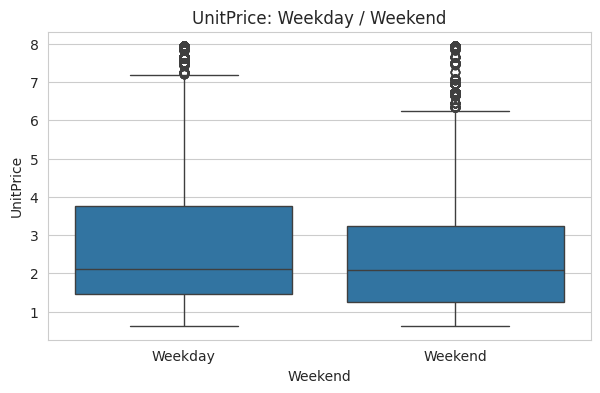

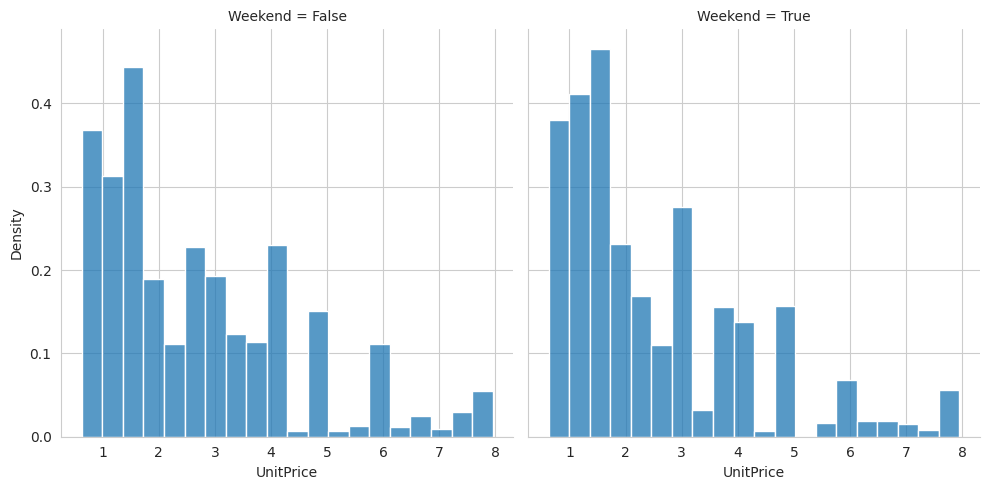

'\n=========================[박스플롯, 히스토그램 해석]=========================\n1. 박스플롯\n  - 주중, 주말 모두 박스플롯 상단에 이상치가 많이 보임\n  - UnitPrice에 고가 상품이 일부 존재함 \n  - 주중보다 주말이 가격대가 높고 변동폭이 큼 (이상치가 많고 박스 두께가 얇음)\n\n2. 히스토그램\n - 주중, 주말 모두 UnitPrice 1~2 구간 막대가 가장 높음 \n - 주중, 주말 모두그래프가 오른쪽으로 갈수록 줄어드는 양의 왜도 형태를 가짐\n - 박스 플롯에서와 마찬가지로 우측 고가 제품이 일부 존재하여 꼬리를 형성\n'

In [124]:
# Q. 상자수염그림과 히스토그램을 그려 시각화를 통해 분포를 확인하고 데이터의 분포에 대해 설명해주세요.

# 박스플롯(상자수염)
plt.figure(figsize=(7,4))
sns.boxplot(x='Weekend', y='UnitPrice', data=df_trim)
plt.xticks([0,1], ['Weekday', 'Weekend'])
plt.title('UnitPrice: Weekday / Weekend')
plt.show()

# 히스토그램
sns.displot(data=df_trim, x='UnitPrice', col='Weekend',
 bins=20, kde=False, stat='density', common_norm=False)
plt.show()

"""
=========================[박스플롯, 히스토그램 해석]=========================
1. 박스플롯
  - 주중, 주말 모두 박스플롯 상단에 이상치가 많이 보임
  - UnitPrice에 고가 상품이 일부 존재함
  - 주중보다 주말이 가격대가 높고 변동폭이 큼 (이상치가 많고 박스 두께가 얇음)

2. 히스토그램
 - 주중, 주말 모두 UnitPrice 1~2 구간 막대가 가장 높음
 - 주중, 주말 모두그래프가 오른쪽으로 갈수록 줄어드는 양의 왜도 형태를 가짐
 - 박스 플롯에서와 마찬가지로 우측 고가 제품이 일부 존재하여 꼬리를 형성
"""

## 4. 상품의 단가와 판매 국가, 판매 날짜을 이용해 판매 수량을 예측하는 회귀 모델을 만드세요.
* 필요한 데이터를 정리하고 결측치와 이상치를 제거해주세요.  
* 변수를 다음과 같이 설정하여 다중 선형 회귀 분석을 진행하세요.
    * 종속변수: 판매 수량(`Quantity`)
    * 독립변수: 상품 단가(`UnitPrice`), 판매 국가(`Country`), 판매 요일(`DayOfWeek`), 판매 월( `InvoiceMonth`)   
* 회귀계수와 결정계수를 활용하여 회귀 분석 결과를 해석해주세요.

In [147]:
# Q. 필요한 데이터를 정리하고 결측치와 이상치를 제거해주세요. -> 앞쪽 상단에서 수행함
df_trim.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID,TotalPrice,DayOfWeek,InvoiceMonth
count,413143.000000,413143,413143.000000,305690.000000,413143.000000,413143.000000,413143.000000
mean,5.517903,2011-07-03 16:56:08.980038656,2.700826,15323.185642,12.139578,2.442655,7.555106
min,1.000000,2010-12-01 08:26:00,0.630000,12347.000000,0.630000,0.000000,1.000000
25%,1.000000,2011-03-24 14:55:00,1.250000,13999.000000,3.320000,1.000000,5.000000
50%,3.000000,2011-07-18 15:56:00,2.100000,15228.000000,8.260000,2.000000,8.000000
75%,8.000000,2011-10-19 11:49:00,3.750000,16818.000000,16.500000,4.000000,11.000000
max,24.000000,2011-12-09 12:50:00,7.950000,18287.000000,183.600000,6.000000,12.000000
std,5.562879,NaN,1.727954,1709.057066,13.253367,1.861101,3.525102


                            OLS Regression Results                            
Dep. Variable:               Quantity   R-squared:                       0.137
Model:                            OLS   Adj. R-squared:                  0.137
Method:                 Least Squares   F-statistic:                     1212.
Date:                Tue, 27 Jan 2026   Prob (F-statistic):               0.00
Time:                        05:48:40   Log-Likelihood:            -1.2648e+06
No. Observations:              413143   AIC:                         2.530e+06
Df Residuals:                  413088   BIC:                         2.530e+06
Df Model:                          54                                         
Covariance Type:            nonrobust                                         
                                         coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Inte

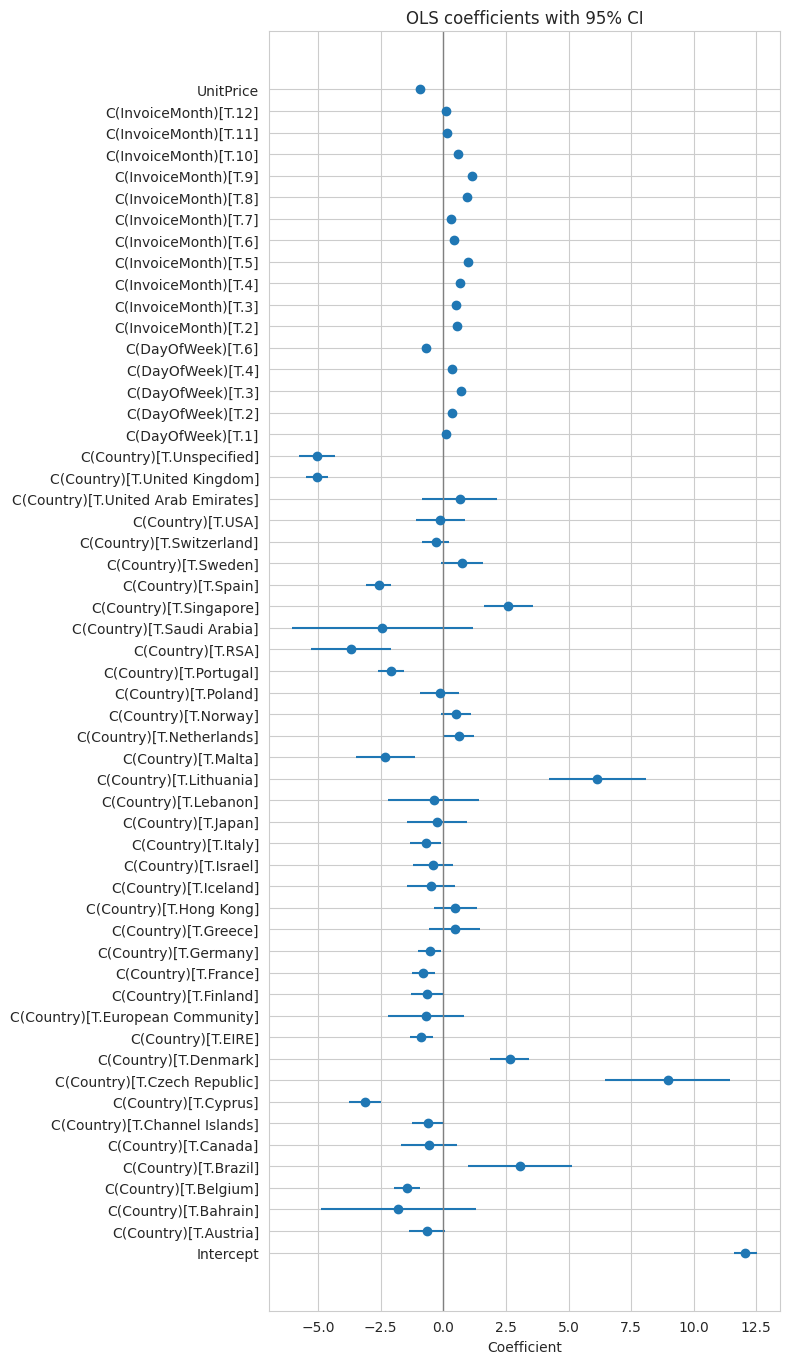

In [137]:
# Q. 변수를 다음과 같이 설정하여 다중 선형 회귀 분석을 진행하세요.
#   종속변수: 판매 수량(Quantity)
#   독립변수: 상품 단가(UnitPrice), 판매 국가(Country), 판매요일(DayOfWeek), 판매 월(InvoiceMonth)

import statsmodels.formula.api as smf # 다중회귀 라이브러리 임포트

# 다중회귀 수행, 변수 처리시 Country, DayOfWeek, InvoiceMonth 는 범주형으로 처리
model = smf.ols(formula="Quantity ~ UnitPrice + C(Country) + C(DayOfWeek) + C(InvoiceMonth)",
    data=df_trim).fit()
print(model.summary())

# 시각화자료 출력

# statsmodels 결과 객체(model)에서 추정된 회귀계수(점추정치) 호출
#   index: 'UnitPrice' 같은 변수명
#   value: 각 변수의 회귀계수(Quantity에 대한 영향의 방향/크기)
params = model.params

# 각 회귀계수 신뢰구간(confidence interval) 계산
#   디폴트 값으로 95% 신뢰구간, 결과는 데이터프레임 (열 2개)
#   DataFrame의 열 이름 low,high로 수정
ci = model.conf_int()
ci.columns = ['low', 'high']


# 회귀계수(params),신뢰구간(ci) 옆으로 붙여서 coef_df 생성
#   coef_df에 각 변수별로 coef, low, high 한 행에 정리
#   concat(axis=1): 열 방향으로 병합
coef_df = pd.concat([params.rename('coef'), ci], axis=1)

plt.figure(figsize=(8, max(4, 0.25*len(coef_df))))
plt.errorbar(coef_df['coef'], coef_df.index,
             xerr=[coef_df['coef']-coef_df['low'], coef_df['high']-coef_df['coef']],
             fmt='o')
plt.axvline(0, color='grey', lw=1)
plt.title('OLS coefficients + 95% CI')
plt.xlabel('Coefficient')
plt.ylabel('')
plt.tight_layout()
plt.show()

In [ ]:
# Q. 회귀계수와 결정계수를 활용하여 회귀 분석 결과를 해석해주세요.
"""
=========================[회귀계수, 결정계수 해석]=========================
1. 결정계수
  - 0.137, 모델이 Quantity 변동의 약 13.7%를 설명
  - 나머지 86.3%는 모델에 없는 요인 이나 노이즈로 발생
  - 결정계수/수정결정계수(Adj. R-squared) 차이가 거의 없으므로 데이터 수가 매우 커서 변수갯수로 인한 패널티가 없었던 것으로 보임

2. 회귀계수
 - UnitPrice 회귀계수 -0.919, 다른 변수 고정했을 때 단가 1 증가하면 판매수량 약 0.92 감소
"""

## 5. 상품 정보와 거래 정보를 바탕으로 해당 거래가 반품될 가능성을 예측하는 로지스틱 회귀 모델을 만드세요.
* 필요한 데이터를 정리하고 결측치와 이상치를 제거해주세요.  
* `Quantity` 피쳐를 활용해 `IsReturn` 피쳐를 생성하세요.
* 모델 학습에 사용할 적절한 피쳐를 선정하세요.
* 모델 학습과 검증을 위해 데이터셋을 train셋과 test셋으로 나누세요.
* `IsReturn`을 예측하는 로지스틱 회귀 모델을 학습하세요.
* 혼동행렬, 정밀도, 재현율, F1-score 등 다양한 평가지표를 사용하여 모델의 성능을 평가하세요.
* 모델의 성능을 더 높일 수 있는 방안에 대해서 고민해보세요.

In [162]:
from sklearn.model_selection import GroupShuffleSplit # 같은 데이터가 train과 test에 동시에 들어가지 않게 분할해주는 도구
from sklearn.compose import ColumnTransformer # 숫자형/범주형처럼 컬럼 타입별로 다른 전처리를 한 번에 수행
from sklearn.pipeline import Pipeline # 전처리→모델학습을 한 덩어리로 묶어 fit/predict를 한 번에 하게 해줌
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer # 결측치를 채움(수치형 중앙값, 범주형 최빈값 등)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score # 예측 결과를 다양한 지표로 평가하기 위한 함수들

# ==================================================
# Q. 필요한 데이터를 정리하고 결측치와 이상치를 제거해주세요.
# Q. Quantity 피쳐를 활용해 IsReturn 피쳐를 생성하세요.
# ==================================================

#   df_trim 은 트리밍 하는 과정에서 음수값(반품정보)이 사라졌으므로 df 데이터 로 다시 시작
df_m = df.copy()  # 트리밍 전 원본 카피하여 별도 저장

# Quantity가 음수면 반품으로 간주하는 컬럼 생성
df_m['IsReturn'] = (df_m['Quantity'] < 0).astype(int)

# Description 결측치는 문자열 'Unknown'으로 채움
df_m['Description'] = df_m['Description'].fillna('Unknown')

# CustomerID결측치도 숫자가 많으니 결측치를  “Unknown” 문자열로 변환
df_m['CustomerID'] = df_m['CustomerID'].astype('Int64').astype(str).replace('<NA>', 'Unknown')

# InvoiceNo가 'C'로 시작하면 취소 표시하는 컬럼 생성
df_m['IsCancelByInvoice'] = df_m['InvoiceNo'].astype(str).str.startswith(('C', 'c')).astype(int)

# ==================================================
# Q. 모델 학습에 사용할 적절한 피쳐를 선정하세요.
# ==================================================
# 타겟 피쳐 y 를 'IsReturn'컬럼 으로 지정
y = df_m['IsReturn']

# 모델 학습 피쳐 X 선정
# Quantity는 타깃 생성에 사용했으므로 에서 제외 하고 선별
# TotalPrice,IsCancelByInvoice 등 정답이 누수될 수 있는 정보를 가진 피쳐는 제외
feature_cols = [
    'StockCode', 'Description', 'UnitPrice', 'CustomerID', 'Country',
   'DayOfWeek', 'InvoiceMonth']
X = df_m[feature_cols]

# ==================================================
# Q. 모델 학습과 검증을 위해 데이터셋을 train셋과 test셋으로 나누세요.
# ==================================================
# GroupShuffleSplit은 그룹을 기준으로 train/test를 분할
# 코드에서 같은 InvoiceNo를 가진 행들은 train 또는 test 한쪽에만 들어가게 됨
# test_size=0.2: 전체 중 20%를 테스트로 사용
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
groups = df_m['InvoiceNo'].astype(str)


# gss.split(): (train 인덱스, test 인덱스)를 여러 번 생성하는 반복자(iterator) 반환
# next()로 첫 번째 분할 결과를 꺼냄
train_idx, test_idx = next(gss.split(X, y, groups=groups))
# 인덱스로 train/test 분리
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]


# ==================================================
# Q. IsReturn을 예측하는 로지스틱 회귀 모델을 학습하세요.
# ==================================================

# 전처리를 위해 수치형/범주형컬럼 분리
numeric_features = ['UnitPrice', 'DayOfWeek', 'InvoiceMonth']
categorical_features = ['StockCode', 'Description', 'CustomerID', 'Country']

# ColumnTransformer는 각 컬럼 그룹에 다른 파이프라인을 적용하고 결과를 합쳐주는 도구
# ColumnTransformer 구조 : (이름, 변환기, 적용 컬럼들)
preprocess = ColumnTransformer(
    transformers=[
        # "num" 파이프라인: 결측치 중앙값으로 대체, StandardScaler 적용
        # 크기/단위가 서로 다르므로 표준화(StandardScaler)가 로지스틱 회귀에 도움
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_features),
        # "cat" 파이프라인: 결측치 최빈값으로 대체, 원-핫 인코딩 적용
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_features),
    ],
    remainder="drop"
)

# 전처리 및 분류 진행
model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced"))
    # max_iter=1000: 수렴 보장 위해 반복 횟수 증가
    # class_weight="balanced":
    # 반품 사례가 희소하면 모델이 “전부 0”을 예측해도 정확도는 높아지는 문제가 생김
    # 이를 막기 위해 클래스 빈도를 고려하여 가중치 자동 조정
])

# 전처리 fit은 train 데이터로만 수행, 같은 변환 규칙 test에 적용
# 결측치 대체, 스케일 평균/표준편차, 원-핫 인코딩 매핑이 train 기준으로 고정
model.fit(X_train, y_train)

# ==================================================
# Q. 혼동행렬, 정밀도, 재현율, F1-score 등 다양한 평가지표를 사용하여 모델의 성능을 평가하세요.
# ==================================================
y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print("Confusion Matrix:\n", cm)
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred, zero_division=0))

Confusion Matrix:
 [[84197 15296]
 [  917  1291]]
Precision: 0.0778
Recall:    0.5847
F1-score:  0.1374

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.85      0.91     99493
           1       0.08      0.58      0.14      2208

    accuracy                           0.84    101701
   macro avg       0.53      0.72      0.52    101701
weighted avg       0.97      0.84      0.90    101701



In [ ]:
# Q. 모델의 성능을 더 높일 수 있는 방안에 대해서 고민해보세요.
"""
1. 클래스 불균형에 따른 위양성 예측
  - 해당 데이터는 전형적인 클래스 불균형(전체 대비 반품 건수가 매우 적음) 문제를 가짐
  - 현재 결과는 반품을 비교적 잘 잡지만(recall), 반품이 아닌데 반품으로 예측하는 위양성이 많음
  - 따라서 정밀도(precision) 개선이 목표라면 임계값을 높여 양성 판정을 보수적으로 하는 방법 고려가능

2. 주의 사항
  - 다만, 위양성(정상 주문을 반품으로 오탐)과 위음성(반품을 놓침, 미탐)의 중요성은 다를 수 있음
  - 따라서 어떤 오류가 더 치명적인지(오탐 최소화 vs 미탐 최소화)를 먼저 결정하고
  - 그 목적에 맞게 모델을 조정해야할 것으로 보임
"""